# Pipeline Tag Prediction
## Baseline - TF-IDF & Logistic Regression

**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook implements the baseline model using TF-IDF and Logistic Regression. It runs in this order:

1. Load cleaned dataset
2. Train/test/validation split
3. Format model card text
5. Setup TF-IDF and encode labels
6. Logistic regression model
7. Predictions and metric analysis
8. Export dataframes for improvement models

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings, re, ast
from datasets import load_dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Cleaned Dataset

Importing the cleaned dataset from `model_cards_cleaned.parquet`. See data cleaning file for specifics.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR = '/content/drive/MyDrive/266-pipeline-tag-prediction'
df = pd.read_parquet(f'{DRIVE_DIR}/model_cards_cleaned.parquet')
metadata = json.load(open(f'{DRIVE_DIR}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']

Mounted at /content/drive


In [ ]:
# Preview dataset for current columns and data formats
df.head()

,modelId,pipeline_tag,label,text,char_len,word_count
0,00000tt/OmniDream-LoRas,text-to-image,7,# OmniDream FinalDream LoRas\n\n<Gallery />\n\...,305,40
1,00001a/gemma-4-26B-A4B-it-uncensored-heretic-a...,image-text-to-text,2,# 🦆 zecanard/gemma-4-26B-A4B-it-uncensored-her...,1343,139
2,001szp/Qwen3.5-27B-Claude-4.6-Opus-Reasoning-D...,image-text-to-text,2,# 🌟 Qwen3.5-27B-Claude-4.6-Opus-Reasoning-Dist...,7758,919
3,0057Kanyakorn/distilbert-base-uncased-finetune...,text-classification,5,<!-- This model card has been generated automa...,1425,187
4,006aman/IKS-Mistral-7B,text-generation,6,# Uploaded finetuned model\n\n- **Developed b...,442,33


## 2. Split Data

Split the data into train, validation, and test dataframes using an 80/20/20 split.

In [ ]:
# train/test split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
# val split
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [ ]:
# Verify shapes for each df
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (111860, 6)
Shape of validation: (13983, 6)
Shape of test: (13982, 6)


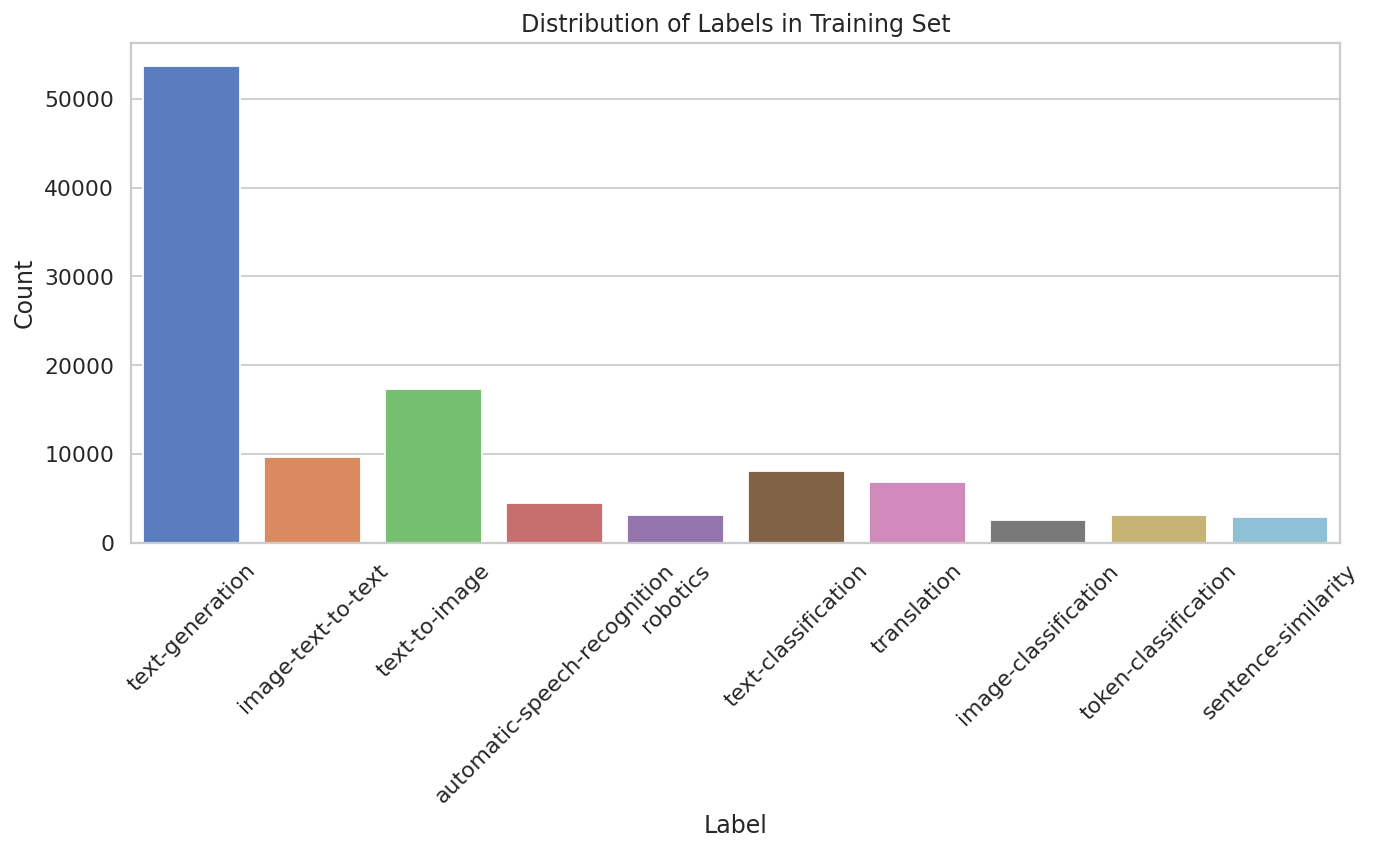

,count
pipeline_tag,
text-generation,53619
text-to-image,17300
image-text-to-text,9666
text-classification,8073
translation,6823
automatic-speech-recognition,4524
token-classification,3159
robotics,3116
sentence-similarity,2971


In [ ]:
# Preview label distribution in the training dataset
sns.countplot(x='pipeline_tag', data=train_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Training Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

train_df["pipeline_tag"].value_counts()

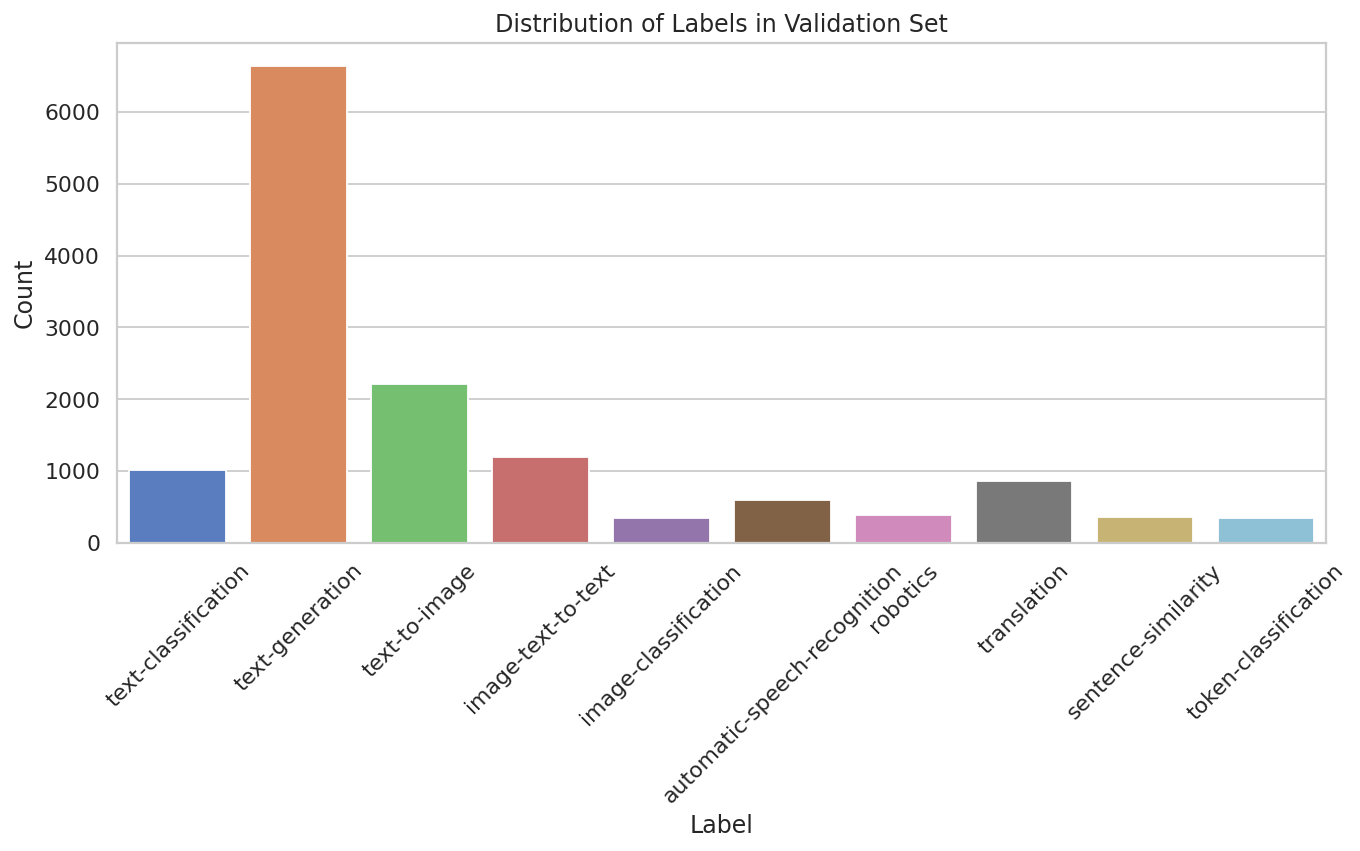

,count
pipeline_tag,
text-generation,6630
text-to-image,2217
image-text-to-text,1201
text-classification,1021
translation,862
automatic-speech-recognition,598
robotics,392
sentence-similarity,363
token-classification,356


In [ ]:
# Preview label distribution in the validation dataset
sns.countplot(x='pipeline_tag', data=val_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Validation Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

val_df["pipeline_tag"].value_counts()

## 3. Format Inputs

Clean the model card text by changing all letters to lowercase, removing punctuation, removing numbers, and collapsing whitespace, prior to fitting the data.

In [ ]:
# Define cleaning function
def clean_text(text: str) -> str:
    """Lowercase, remove punctuation/numbers, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
# Apply clean_text to train set
train_df['text_clean']  = train_df['text'].apply(clean_text)
# Apply clean_text to test set
test_df['text_clean']  = test_df['text'].apply(clean_text)
# Apply clean_text to validation set
val_df['text_clean']  = val_df['text'].apply(clean_text)

In [ ]:
# Print a cleaned example

# raw unformatted:
print(f'\ntrain: raw answer  : "{train_df["text"].iloc[0]}"')


train: raw answer  : "# Kairos-V0.1-1.5B-Instruct

## Introduction

**Kairos** is a fine-tuned AI assistant built by **ACAI** (Assisting with Compassion and Artificial Intelligence) -- the AI platform built exclusively for nonprofits and philanthropy.

Kairos is fine-tuned with nonprofit and philanthropy domain knowledge: fundraising, grants, donor stewardship, impact measurement, SDGs, program design, and operations. It identifies as Kairos and knows about the ACAI platform.

This is the first release in the Kairos model series.

| Feature | Details |
|---------|---------|
| **Parameters** | 1.5B |
| **Fine-Tuning Method** | QLoRA (4-bit, r=32, alpha=64) |
| **Training Data** | 490+ curated examples including 42 long-form expert answers (identity, nonprofit domain, ACAI platform) |
| **Context Length** | 2048 tokens |
| **License** | Apache 2.0 |
| **Author** | [ACAI](https://huggingface.co/buildacai) |
| **Platform** | [buildacai.com](https://buildacai.com) |

## Quickstart

```pyth

In [ ]:
# Print the cleaned version of the above example:

# cleaned
print(f'train: clean answer : "{train_df["text_clean"].iloc[0]}"')

train: clean answer : "kairos v b instruct introduction kairos is a fine tuned ai assistant built by acai assisting with compassion and artificial intelligence the ai platform built exclusively for nonprofits and philanthropy kairos is fine tuned with nonprofit and philanthropy domain knowledge fundraising grants donor stewardship impact measurement sdgs program design and operations it identifies as kairos and knows about the acai platform this is the first release in the kairos model series feature details parameters b fine tuning method qlora bit r alpha training data curated examples including long form expert answers identity nonprofit domain acai platform context length tokens license apache author acai https huggingface co buildacai platform buildacai com https buildacai com quickstart python from transformers import automodelforcausallm autotokenizer model name buildacai kairos v b instruct tokenizer autotokenizer from pretrained model name model automodelforcausallm from pretr

## 4. TF-IDF & Encoding

Setup the TF-IDF vectorizer. Set the max_features to 20,000 as a starting point. Encode the `pipeline_tag` labels. Fit data with training and validation sets. Do not fit using test data.

In [ ]:
# Set TF-IDF
tf_idf_vec = TfidfVectorizer(max_features=20000,
                             ngram_range=(1,2),
                             sublinear_tf=True,
                             min_df=5,
                             norm='l2'
                             )

In [ ]:
label_encoder = LabelEncoder()

# Fit w/ training and val
X_train = tf_idf_vec.fit_transform(train_df["text_clean"])
X_val = tf_idf_vec.transform(val_df["text_clean"])

# Fit w/ test
X_test = tf_idf_vec.transform(test_df["text_clean"])

# Encode text labels to int categories
Y_train = label_encoder.fit_transform(train_df["pipeline_tag"])
Y_val = label_encoder.transform(val_df["pipeline_tag"])
Y_test = label_encoder.transform(test_df["pipeline_tag"])

# Print shapes for review
print("Shape of formatted X_train:", X_train.shape)
print("Shape of formatted X_val:", X_val.shape)
print("Shape of formatted X_test:", X_test.shape)
print("Shape of formatted Y_train:", Y_train.shape)
print("Shape of formatted Y_val:", Y_val.shape)
print("Shape of formatted Y_test:", Y_test.shape)

Shape of formatted X_train: (111860, 20000)
Shape of formatted X_val: (13983, 20000)
Shape of formatted X_test: (13982, 20000)
Shape of formatted Y_train: (111860,)
Shape of formatted Y_val: (13983,)
Shape of formatted Y_test: (13982,)


## 5. Logistic Regression Baseline

In [ ]:
# Baseline w/ Logistic Regression
lr_model = LogisticRegression(max_iter=1000,
                              class_weight="balanced",
                              random_state=42,
                              n_jobs=-1
                              )

lr_model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

## 6. Predictions and Metrics

Use the logistic regression model to generate predictions for the validation and finally the test datasets. Generate accuracy and macro-F1 scores to evaluate the model on each dataset.

In [ ]:
# Save predictions
val_predictions = lr_model.predict(X_val)
test_predictions = lr_model.predict(X_test)

In [ ]:
# Print relevant metrics
print("Validation Accuracy:", accuracy_score(Y_val, val_predictions))
print("Validation Macro-F1:", f1_score(Y_val, val_predictions, average="macro"))

print("Test Accuracy:", accuracy_score(Y_test, test_predictions))
print("Test Macro-F1:", f1_score(Y_test, test_predictions, average="macro"))

Validation Accuracy: 0.9451476793248945
Validation Macro-F1: 0.9495347218039265
Test Accuracy: 0.9452152767844372
Test Macro-F1: 0.9513239173863031


In [ ]:
# Print classification report to analyze metrics per `pipeline_tag` label
print(classification_report(Y_test, test_predictions, target_names=label_encoder.classes_))

                              precision    recall  f1-score   support

automatic-speech-recognition       0.98      0.99      0.98       607
        image-classification       0.94      0.98      0.96       315
          image-text-to-text       0.73      0.91      0.81      1228
                    robotics       0.97      0.99      0.98       355
         sentence-similarity       0.98      0.99      0.98       370
         text-classification       0.91      0.94      0.92      1027
             text-generation       0.97      0.92      0.95      6617
               text-to-image       1.00      0.99      0.99      2151
        token-classification       0.96      0.94      0.95       435
                 translation       0.98      0.98      0.98       877

                    accuracy                           0.95     13982
                   macro avg       0.94      0.96      0.95     13982
                weighted avg       0.95      0.95      0.95     13982



## 7. Export data

Export the train, test, and validation dataframes to use the exact same data split for the improvement models: RoBERTa and ModernBERT. This ensures consistency in our metric and model evaluations.

In [ ]:
# Set new google drive directory path
DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'
# Save each dataframe to a parquet
train_df.to_parquet(f'{DRIVE_DIR}/train_df.parquet', index=False)
val_df.to_parquet(f'{DRIVE_DIR}/val_df.parquet', index=False)
test_df.to_parquet(f'{DRIVE_DIR}/test_df.parquet', index=False)

To load these dataframes into a new notebook for the improvement model, use this code block:

```python
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

train_df = pd.read_parquet(f'{DRIVE_DIR_2}/train_df.parquet')
val_df = pd.read_parquet(f'{DRIVE_DIR_2}/val_df.parquet')
test_df = pd.read_parquet(f'{DRIVE_DIR_2}/test_df.parquet')

metadata = json.load(open(f'{DRIVE_DIR_2}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']
```

## 00. random working space

misc data checks - `delete later`

In [ ]:
max_length = train_df["text"].str.len().max()
max_length

99615

In [ ]:
avg_len = train_df["text"].str.len().mean()
avg_len

np.float64(4357.699946361523)

In [ ]:
train_df["text"].str.len().describe()

,text
count,111860.000000
mean,4357.699946
std,7880.485083
min,100.000000
25%,1061.000000
50%,2022.000000
75%,4500.250000
max,99615.000000
